<a href="https://colab.research.google.com/github/Ashishjoshi794/CNN/blob/main/tumour_detection_using_deep_learning1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

In [ ]:

# directories for training and testion data
train_dir = "/content/drive/MyDrive/archive/Training"
test_dir  = "/content/drive/MyDrive/archive/Testing"
#load and shuffle the train data

In [ ]:
# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [ ]:
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)
train_paths

['/content/drive/MyDrive/archive/Training/pituitary/Tr-pi_761.jpg',
 '/content/drive/MyDrive/archive/Training/notumor/Tr-no_1041.jpg',
 '/content/drive/MyDrive/archive/Training/pituitary/Tr-pi_31.jpg',
 '/content/drive/MyDrive/archive/Training/meningioma/Tr-me_214.jpg',
 '/content/drive/MyDrive/archive/Training/pituitary/Tr-pi_1299.jpg',
 '/content/drive/MyDrive/archive/Training/pituitary/Tr-pi_913.jpg',
 '/content/drive/MyDrive/archive/Training/glioma/Tr-gl_186.jpg',
 '/content/drive/MyDrive/archive/Training/glioma/Tr-gl_1094.jpg',
 '/content/drive/MyDrive/archive/Training/meningioma/Tr-me_140.jpg',
 '/content/drive/MyDrive/archive/Training/notumor/Tr-no_408.jpg',
 '/content/drive/MyDrive/archive/Training/glioma/Tr-gl_1191.jpg',
 '/content/drive/MyDrive/archive/Training/glioma/Tr-gl_1246.jpg',
 '/content/drive/MyDrive/archive/Training/meningioma/Tr-me_706.jpg',
 '/content/drive/MyDrive/archive/Training/pituitary/Tr-pi_1106.jpg',
 '/content/drive/MyDrive/archive/Training/meningioma/Tr-

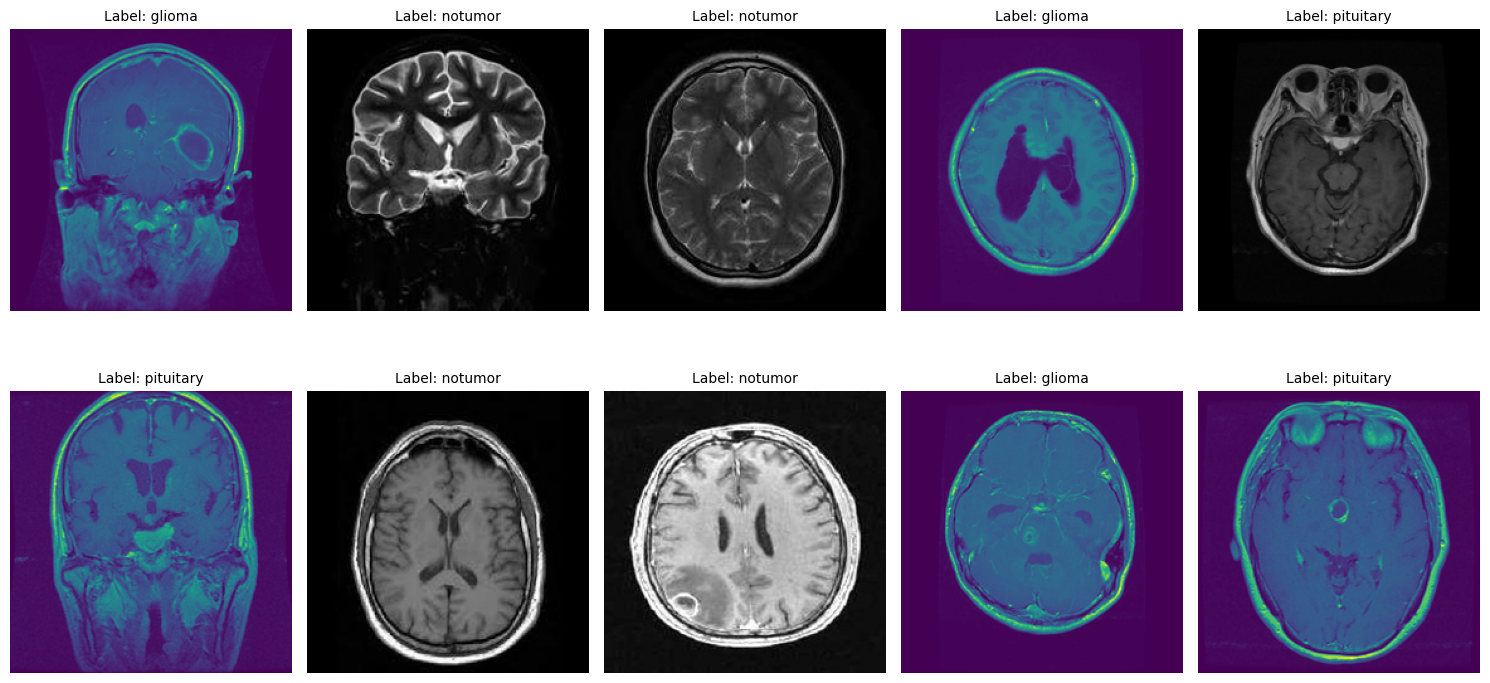

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [ ]:
# Model architecture
IMAGE_SIZE = 128  # Image size
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 3121s 11s/step - loss: 0.4876 - sparse_categorical_accuracy: 0.8112
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 119ms/step - loss: 0.2562 - sparse_categorical_accuracy: 0.9041
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 119ms/step - loss: 0.1565 - sparse_categorical_accuracy: 0.9398
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - loss: 0.1260 - sparse_categorical_accuracy: 0.9545
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - loss: 0.0948 - sparse_categorical_accuracy: 0.9634


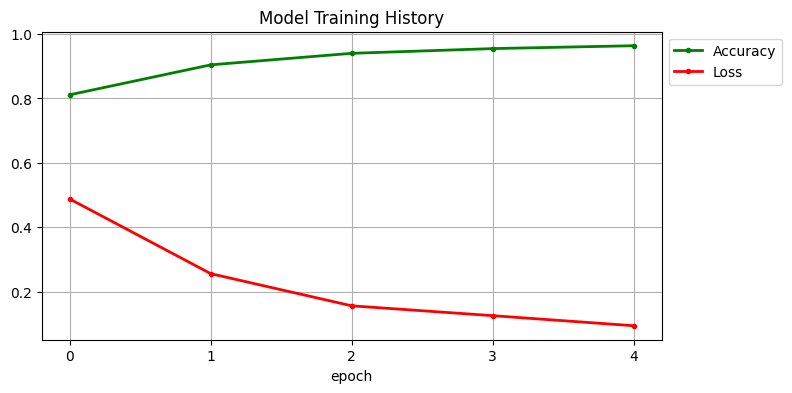

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       400
           1       0.95      0.78      0.86       400
           2       0.92      1.00      0.96       400
           3       0.94      0.98      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



Confusion Matrix:
[[364  13   3  20]
 [ 50 313  32   5]
 [  1   0 399   0]
 [  4   3   0 393]]


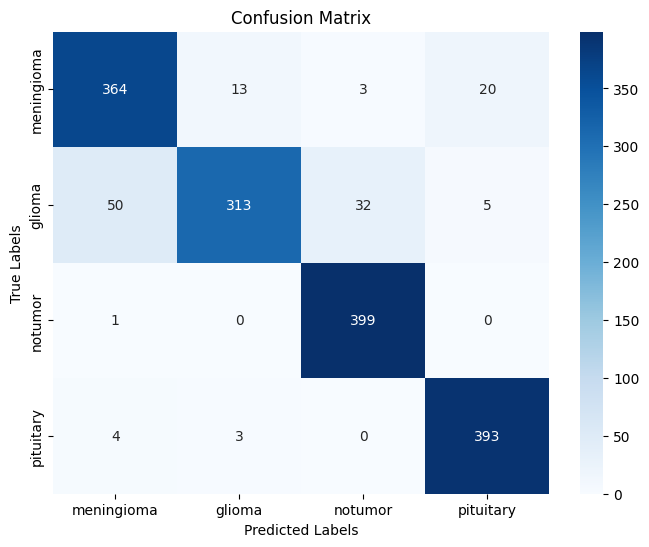

In [ ]:

# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

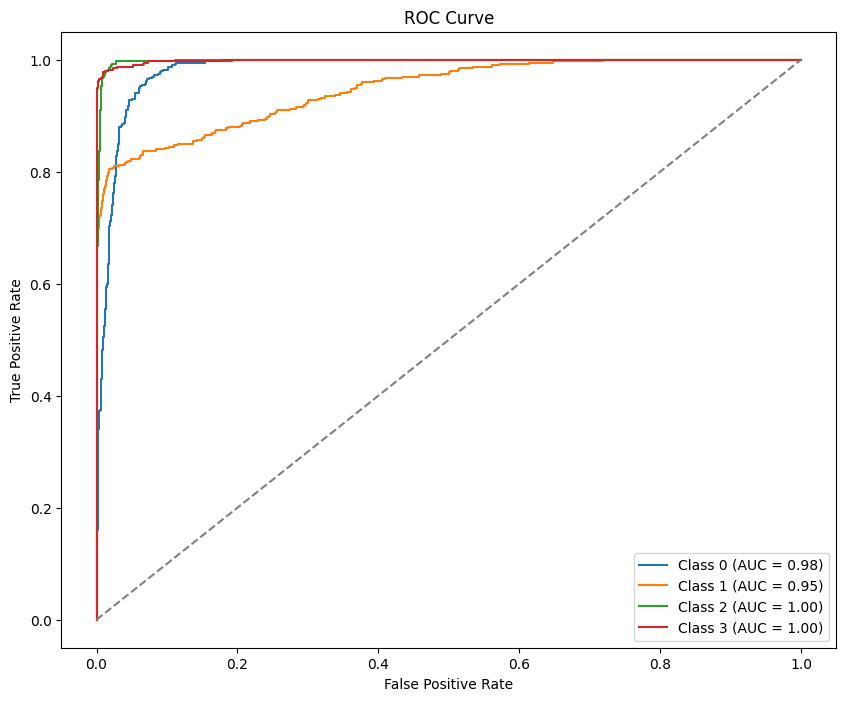

In [ ]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Save the entire model
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma','meningioma','notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):

    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


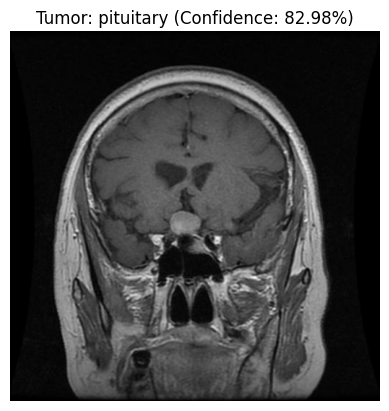

In [ ]:
image_path = '/content/drive/MyDrive/archive/Testing/pituitary/Te-pi_1.jpg'
detect_and_display(image_path, model)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# -------------------------
# PREPROCESS IMAGE
# -------------------------
def preprocess_image(img_path, size=128):

    img = load_img(img_path, target_size=(size, size))

    img_array = img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    return img_array

# -------------------------
# GRAD-CAM FUNCTION
# -------------------------
def display_gradcam(img_path, model):

    img_array = preprocess_image(img_path)

    # IMPORTANT: force model call - this ensures the model is built and weights are loaded
    _ = model(img_array)

    # Get the VGG16 sub-model (named 'vgg16') from the sequential model
    vgg_base = model.get_layer('vgg16')

    # Define a new Input tensor for the Grad-CAM functional models
    # Use explicit IMAGE_SIZE (128) and channels (3) to define the input shape
    grad_cam_input = tf.keras.Input(shape=(128, 128, 3)) # Assuming IMAGE_SIZE is 128

    # --- 1. Construct the path to get block5_conv3 output from grad_cam_input ---
    conv_layer_name = 'block5_conv3'
    try:
        # Create a functional model that takes `vgg_base`'s input and outputs `block5_conv3`
        conv_outputs_for_grad = tf.keras.models.Model(
            inputs=vgg_base.inputs,
            outputs=vgg_base.get_layer(conv_layer_name).output
        )(grad_cam_input)
    except ValueError:
        raise ValueError(f"Target convolutional layer '{conv_layer_name}' not found or accessible in VGG16 base.")

    # --- 2. Construct the path to get final predictions from grad_cam_input ---
    x_pred_path = grad_cam_input
    # Pass through the VGG16 base model first
    x_pred_path = vgg_base(x_pred_path) # Output shape will be (None, 4, 4, 512) for 128x128 input

    # Explicitly flatten the tensor using tf.reshape
    # This bypasses potential issues with reusing the Flatten layer instance from a loaded model
    flat_dim = tf.math.reduce_prod(tf.shape(x_pred_path)[1:])
    x_pred_path = tf.reshape(x_pred_path, [-1, flat_dim]) # Reshape to (None, 8192)

    # Apply the remaining classification layers (Dropout, Dense, Dropout, Dense)
    # model.layers[0] is InputLayer, model.layers[1] is 'vgg16', model.layers[2] is 'Flatten'.
    # We start from index 3 for the remaining Dropout and Dense layers.
    for i in range(3, len(model.layers)):
        x_pred_path = model.layers[i](x_pred_path)

    predictions_for_grad = x_pred_path

    # Create the combined gradient model
    grad_model = tf.keras.models.Model(
        inputs=grad_cam_input,
        outputs=[conv_outputs_for_grad, predictions_for_grad]
    )

    # Gradient calculation
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        predicted_class = tf.argmax(predictions[0])

        loss = predictions[:, predicted_class]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    heatmap = heatmap / np.max(heatmap + 1e-8)

    # Load original image
    img = cv2.imread(img_path)

    img = cv2.resize(img, (128, 128))

    # Resize heatmap
    heatmap = cv2.resize(heatmap.numpy(), (128, 128))

    heatmap = np.uint8(255 * heatmap)

    # Apply color map
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Display
    plt.figure(figsize=(7,7))

    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))

    plt.title("Grad-CAM Tumor Localization")

    plt.axis("off")

    plt.show()

In [ ]:
image_path = "/content/drive/MyDrive/archive/Testing/pituitary/Te-pi_1.jpg"

display_gradcam(image_path, model)

ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```
